In [29]:
import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

!pip install pyarrow

df_cp  = pd.read_csv('/Users/sandramartinez/Desktop/Proyectos_Data/TFM-EasyMoney/grupo-1-dscesp-0226/data/customer_products.csv', index_col=0)
df_cs  = pd.read_csv('/Users/sandramartinez/Desktop/Proyectos_Data/TFM-EasyMoney/grupo-1-dscesp-0226/data/customer_sociodemographics.csv', index_col=0)
df_cca = pd.read_csv('/Users/sandramartinez/Desktop/Proyectos_Data/TFM-EasyMoney/grupo-1-dscesp-0226/data/customer_commercial_activity.csv', index_col=0)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.2/31.2 MB 48.2 MB/s  0:00:00m0:00:0100:01


# Limpieza de df_cp (customer_products)

In [5]:
df_cp.columns

Index(['pk_cid', 'pk_partition', 'short_term_deposit', 'loans', 'mortgage',
       'funds', 'securities', 'long_term_deposit', 'em_account_pp',
       'credit_card', 'payroll', 'pension_plan', 'payroll_account',
       'emc_account', 'debit_card', 'em_account_p', 'em_acount'],
      dtype='object')

In [ ]:
product_cols = ['short_term_deposit','loans','mortgage','funds','securities',
                 'long_term_deposit','em_account_pp','credit_card','payroll',
                 'pension_plan','payroll_account','emc_account','debit_card',
                 'em_account_p','em_acount']

print(df_cp[product_cols].isnull().sum())  # revisamos antes de imputar

# Imputar nulos, si el flag de producto es nulo, es que no lo tiene -> 0
df_cp[product_cols] = df_cp[product_cols].fillna(0).astype(int)

short_term_deposit     0
loans                  0
mortgage               0
funds                  0
securities             0
long_term_deposit      0
em_account_pp          0
credit_card            0
payroll               61
pension_plan          61
payroll_account        0
emc_account            0
debit_card             0
em_account_p           0
em_acount              0
dtype: int64


# Limpieza de df_cs (customer_sociodemographics)

In [ ]:
print(df_cs.isnull().sum())

# country_id y deceased:
print(df_cs['country_id'].value_counts())
df_cs = df_cs.drop(columns=['country_id'])  # si es casi siempre "ES", no aporta info

print(df_cs['deceased'].value_counts())
# Un cliente fallecido no puede ser objetivo de ninguna campaña de cross-selling
df_cs = df_cs[df_cs['deceased'] == 'N'].drop(columns=['deceased'])

# Imputar nulos moda para gender y region_code, mediana para salary
df_cs['gender'] = df_cs['gender'].fillna(df_cs['gender'].mode()[0])
df_cs['region_code'] = df_cs['region_code'].fillna(df_cs['region_code'].mode()[0])
df_cs['salary'] = df_cs['salary'].fillna(df_cs['salary'].median())

pk_cid                0
pk_partition          0
country_id            0
region_code        2264
gender               25
age                   0
deceased              0
salary          1541104
dtype: int64
country_id
ES    5960672
GB        441
FR        225
DE        199
US        195
CH        194
BR         87
BE         81
VE         79
IE         68
MX         58
AT         51
AR         51
PL         49
IT         45
MA         34
CL         30
CN         28
CA         22
LU         17
ET         17
QA         17
CI         17
SA         17
CM         17
SN         17
MR         17
NO         17
RU         17
CO         17
GA         17
GT         17
DO         17
SE         16
DJ         11
PT         11
JM         11
RO          9
HU          8
DZ          7
PE          4
Name: count, dtype: int64
deceased
N    5961849
S       1075
Name: count, dtype: int64


# Limpieza de df_cca (customer_commercial_activity)

In [8]:
print(df_cca.isnull().sum())

def moda_segura(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else np.nan

# Caso 1: falta entry_channel pero hay segment -> moda por segment
mask_solo_canal = df_cca['entry_channel'].isnull() & df_cca['segment'].notnull()
moda_por_segmento = df_cca.groupby('segment')['entry_channel'].agg(moda_segura)
df_cca.loc[mask_solo_canal, 'entry_channel'] = df_cca.loc[mask_solo_canal, 'segment'].map(moda_por_segmento)

# Caso 2: falta segment pero hay entry_channel -> moda por entry_channel
mask_solo_segmento = df_cca['segment'].isnull() & df_cca['entry_channel'].notnull()
moda_por_canal = df_cca.groupby('entry_channel')['segment'].agg(moda_segura)
df_cca.loc[mask_solo_segmento, 'segment'] = df_cca.loc[mask_solo_segmento, 'entry_channel'].map(moda_por_canal)

# Caso 3 + cualquier resto que siga nulo (ambos a la vez, o sin moda disponible en su grupo)
df_cca['entry_channel'] = df_cca['entry_channel'].fillna('Desconocido')
df_cca['segment'] = df_cca['segment'].fillna('Desconocido')

df_cca['active_customer'] = df_cca['active_customer'].fillna(0).astype(int)

pk_cid                  0
pk_partition            0
entry_date              0
entry_channel      132423
active_customer         0
segment            133944
dtype: int64


# Fechas y orden (en las 3 tablas)

In [9]:
for df in [df_cp, df_cs, df_cca]:
    df['pk_partition'] = pd.to_datetime(df['pk_partition'], format='%Y-%m')
    df.sort_values(['pk_cid', 'pk_partition'], inplace=True)

# Verificación final: no deberían quedar nulos relevantes
print('df_cp nulos:', df_cp.isnull().sum().sum())
print('df_cs nulos:', df_cs.isnull().sum().sum())
print('df_cca nulos:', df_cca.isnull().sum().sum())

df_cp nulos: 0
df_cs nulos: 0
df_cca nulos: 0


In [10]:
# Unimos df_cp con df_cs: usamos "inner" a propósito, porque en df_cs ya quitamos
# los meses donde el cliente estaba fallecido -> el inner join hace que esos
# meses desaparezcan también del panel final, sin tener que filtrarlos otra vez.
df_panel = df_cp.merge(df_cs, on=['pk_cid', 'pk_partition'], how='inner')

# Unimos con df_cca. Aquí no hemos filtrado nada, así que en principio debería
# encajar 1 a 1, pero usamos "left" para no perder filas si faltase alguna
# combinación cliente+mes en df_cca.
df_panel = df_panel.merge(df_cca, on=['pk_cid', 'pk_partition'], how='left')

print("Forma del panel final:", df_panel.shape)
print("Nulos totales tras el merge:", df_panel.isnull().sum().sum())
print(df_panel.isnull().sum()[df_panel.isnull().sum() > 0])  # por si aparece alguno nuevo

Forma del panel final: (5961849, 25)
Nulos totales tras el merge: 0
Series([], dtype: int64)


### Calculamos el target
¿fue este el mes en que este cliente contrató pension_plan por primera vez?

target = 1 → justo este mes pasó de no tenerlo a tenerlo (una adquisición nueva).

target = 0 → cualquier otra situación: nunca lo ha tenido, ya lo tenía desde antes, o es el primer mes del cliente en los datos.

In [11]:
# Nos aseguramos de que el orden es correcto antes de calcular nada por cliente-mes
df_panel = df_panel.sort_values(['pk_cid', 'pk_partition']).reset_index(drop=True)

# diff() calcula, PARA CADA CLIENTE POR SEPARADO (gracias al groupby), la diferencia
# entre el valor de pension_plan de este mes y el del mes anterior.
#   0 -> 1  => diff = 1   (justo lo que buscamos: adquisición nueva)
#   1 -> 1  => diff = 0   (ya lo tenía, no es "nuevo")
#   0 -> 0  => diff = 0   (sigue sin tenerlo)
#   primer mes de cada cliente -> diff = NaN (no hay mes anterior con el que comparar)
df_panel['target'] = df_panel.groupby('pk_cid')['pension_plan'].diff()

# Nos quedamos solo con el caso que nos interesa: 1 = adquisición nueva, todo lo demás = 0
# (esto también convierte los NaN del primer mes en 0, sin problema: esas filas las
# vamos a descartar más adelante de todas formas, porque no tendrán lag disponible)
df_panel['target'] = df_panel['target'].apply(lambda x: 1 if x == 1 else 0)

print(df_panel['target'].value_counts())
print(f"Total de adquisiciones nuevas de pension_plan: {df_panel['target'].sum()}")

target
0    5924994
1      36855
Name: count, dtype: int64
Total de adquisiciones nuevas de pension_plan: 36855


In [ ]:
# Ahora seleccionamos las features y les aplicamos el lag-1.

# Variable derivada sencilla: cuántos productos tiene el cliente ese mes en total
product_cols = ['short_term_deposit','loans','mortgage','funds','securities',
                 'long_term_deposit','em_account_pp','credit_card','payroll',
                 'pension_plan','payroll_account','emc_account','debit_card',
                 'em_account_p','em_acount']
df_panel['num_products'] = df_panel[product_cols].sum(axis=1)

# Features iniciales: pocas y sencillas a propósito (siempre se puede ampliar después)
features_base = ['age', 'salary', 'gender', 'segment', 'entry_channel',
                  'active_customer', 'num_products', 'pension_plan']

# shift(1) agrupado por cliente: mueve cada valor "una fila hacia abajo" DENTRO
# del histórico de ese mismo cliente. El resultado: en la fila del mes T, la
# columna "_lag1" contiene el valor que tenía esa variable en el mes T-1.
for col in features_base:
    df_panel[f'{col}_lag1'] = df_panel.groupby('pk_cid')[col].shift(1)

print(df_panel[[f'{c}_lag1' for c in features_base]].isnull().sum())
print("Clientes únicos en el panel:", df_panel['pk_cid'].nunique())

age_lag1                456318
salary_lag1             456318
gender_lag1             456318
segment_lag1            456318
entry_channel_lag1      456318
active_customer_lag1    456318
num_products_lag1       456318
pension_plan_lag1       456318
dtype: int64
Clientes únicos en el panel: 456318


In [13]:
# quitar esas filas sin lag, y quedarnos solo con el universo elegible.

# 1) Quitamos el primer mes de cada cliente (las filas sin lag que acabamos de ver)
df_model = df_panel.dropna(subset=[f'{c}_lag1' for c in features_base]).copy()

# 2) Nos quedamos SOLO con clientes que el mes anterior no tenían pension_plan
#    (son los únicos que pueden generar un target=1 real, y a los únicos que
#    tendría sentido ofrecerles el producto)
df_model = df_model[df_model['pension_plan_lag1'] == 0].copy()

print("Filas en el panel completo:", df_panel.shape[0])
print("Filas tras quitar primer mes y filtrar elegibles:", df_model.shape[0])
print(df_model['target'].value_counts())

Filas en el panel completo: 5961849
Filas tras quitar primer mes y filtrar elegibles: 5305179
target
0    5268324
1      36855
Name: count, dtype: int64


In [14]:
# el split por fecha, no aleatorio

# Detectamos automáticamente los meses disponibles, ordenados de más antiguo a más reciente
meses = sorted(df_model['pk_partition'].unique())
mes_val = meses[-1]   # el último mes -> validación
mes_test = meses[-2]  # el penúltimo mes -> test

print("Mes de test:", mes_test, "| Mes de validación:", mes_val)

train = df_model[df_model['pk_partition'] < mes_test]
test = df_model[df_model['pk_partition'] == mes_test]
val = df_model[df_model['pk_partition'] == mes_val]

print("Train:", train.shape)
print("Test: ", test.shape)
print("Val:  ", val.shape)

print("\nDistribución target en train:\n", train['target'].value_counts())
print("\nDistribución target en test:\n", test['target'].value_counts())
print("\nDistribución target en val:\n", val['target'].value_counts())

Mes de test: 2019-04-01 00:00:00 | Mes de validación: 2019-05-01 00:00:00
Train: (4464025, 35)
Test:  (418993, 35)
Val:   (422161, 35)

Distribución target en train:
 target
0    4432235
1      31790
Name: count, dtype: int64

Distribución target en test:
 target
0    416719
1      2274
Name: count, dtype: int64

Distribución target en val:
 target
0    419370
1      2791
Name: count, dtype: int64


In [15]:
# pension_plan_lag1 ya no sirve como feature: tras filtrar el universo elegible,
# vale 0 en TODAS las filas (lo usamos solo para filtrar, no para predecir).
cat_cols = ['gender_lag1', 'segment_lag1', 'entry_channel_lag1']
num_cols = ['age_lag1', 'salary_lag1', 'active_customer_lag1', 'num_products_lag1']

# One-Hot Encoding: convierte cada categoría en una columna 0/1 propia
# (ej. "gender_lag1" se convierte en "gender_lag1_V", "gender_lag1_H"...)
X_train = pd.get_dummies(train[num_cols + cat_cols], columns=cat_cols)
X_test  = pd.get_dummies(test[num_cols + cat_cols], columns=cat_cols)
X_val   = pd.get_dummies(val[num_cols + cat_cols], columns=cat_cols)

# Alineamos test y val con las columnas de train, por si alguna categoría rara
# solo aparece en un mes y no en otro (si falta, se rellena con 0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

y_train = train['target']
y_test = test['target']
y_val = val['target']

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("X_val:  ", X_val.shape)
print(list(X_train.columns))

X_train: (4464025, 75)
X_test:  (418993, 75)
X_val:   (422161, 75)
['age_lag1', 'salary_lag1', 'active_customer_lag1', 'num_products_lag1', 'gender_lag1_H', 'gender_lag1_V', 'segment_lag1_01 - TOP', 'segment_lag1_02 - PARTICULARES', 'segment_lag1_03 - UNIVERSITARIO', 'segment_lag1_Desconocido', 'entry_channel_lag1_004', 'entry_channel_lag1_007', 'entry_channel_lag1_013', 'entry_channel_lag1_Desconocido', 'entry_channel_lag1_KAA', 'entry_channel_lag1_KAB', 'entry_channel_lag1_KAD', 'entry_channel_lag1_KAE', 'entry_channel_lag1_KAF', 'entry_channel_lag1_KAG', 'entry_channel_lag1_KAH', 'entry_channel_lag1_KAI', 'entry_channel_lag1_KAJ', 'entry_channel_lag1_KAK', 'entry_channel_lag1_KAM', 'entry_channel_lag1_KAQ', 'entry_channel_lag1_KAR', 'entry_channel_lag1_KAS', 'entry_channel_lag1_KAT', 'entry_channel_lag1_KAW', 'entry_channel_lag1_KAY', 'entry_channel_lag1_KAZ', 'entry_channel_lag1_KBG', 'entry_channel_lag1_KBH', 'entry_channel_lag1_KBO', 'entry_channel_lag1_KBU', 'entry_channel_lag1_

In [16]:
# Calculamos qué tan frecuente es cada canal de entrada, PERO SOLO con datos de train
# (si lo calculásemos con todo el dataset, estaríamos usando información de test/val
# para decidir cómo agrupar train -> sería una fuga de información sutil).
frecuencias = train['entry_channel_lag1'].value_counts(normalize=True)
categorias_frecuentes = frecuencias[frecuencias >= 0.01].index  # se queda con las que son >=1% de train

def agrupar_entry_channel(serie):
    return serie.where(serie.isin(categorias_frecuentes), 'Otros')

train = train.copy()
test = test.copy()
val = val.copy()
train['entry_channel_lag1'] = agrupar_entry_channel(train['entry_channel_lag1'])
test['entry_channel_lag1']  = agrupar_entry_channel(test['entry_channel_lag1'])
val['entry_channel_lag1']   = agrupar_entry_channel(val['entry_channel_lag1'])

print("Categorías de entry_channel tras agrupar:", train['entry_channel_lag1'].nunique())

# Repetimos el One-Hot Encoding ya con las categorías agrupadas
X_train = pd.get_dummies(train[num_cols + cat_cols], columns=cat_cols)
X_test  = pd.get_dummies(test[num_cols + cat_cols], columns=cat_cols)
X_val   = pd.get_dummies(val[num_cols + cat_cols], columns=cat_cols)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

y_train = train['target']
y_test = test['target']
y_val = val['target']

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("X_val:  ", X_val.shape)

Categorías de entry_channel tras agrupar: 11
X_train: (4464025, 21)
X_test:  (418993, 21)
X_val:   (422161, 21)


#### entrenamos el primer modelo

In [18]:
# max_depth=5: un árbol poco profundo, fácil de interpretar y con menos riesgo
# de sobreajustarse a los datos de entrenamiento.
# class_weight='balanced': el propio modelo compensa que solo el 0,7% del
# train sea target=1, dándole más peso a esos casos en vez de tirar datos.
modelo = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


#### evaluamos sobre el set de test (abril 2019, el mes que el modelo no ha visto nunca).

              precision    recall  f1-score   support

   No compra       1.00      0.73      0.84    416719
      Compra       0.02      0.87      0.03      2274

    accuracy                           0.73    418993
   macro avg       0.51      0.80      0.44    418993
weighted avg       0.99      0.73      0.84    418993



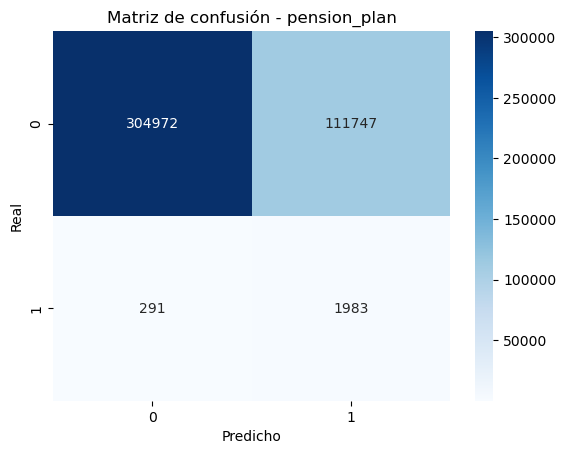

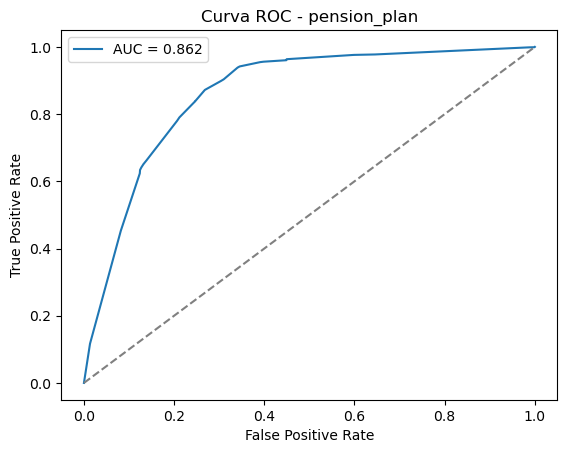

In [20]:
y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]  # probabilidad de la clase "1 = compra"

print(classification_report(y_test, y_pred, target_names=['No compra', 'Compra']))

# Matriz de confusión: cuántos aciertos y errores de cada tipo comete el modelo
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusión - pension_plan')
plt.show()

# Curva ROC: OJO, se calcula con predict_proba (probabilidad), NUNCA con predict
# (ese fue justo el error que vimos en el notebook de "otro año")
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - pension_plan')
plt.legend()
plt.show()

# simulación

In [21]:
val_proba = modelo.predict_proba(X_val)[:, 1]

# Montamos una tabla: cada cliente, su probabilidad predicha, y si compró de verdad
df_sim = pd.DataFrame({
    'pk_cid': val['pk_cid'].values,
    'probabilidad': val_proba,
    'compra_real': y_val.values
}).sort_values(by='probabilidad', ascending=False)

top_pct = 0.05
top_n = int(len(df_sim) * top_pct)
top_clientes = df_sim.head(top_n)

compras_en_top = top_clientes['compra_real'].sum()
tasa_conversion_top = compras_en_top / top_n
tasa_base = df_sim['compra_real'].mean()

print(f"Clientes evaluados en validación (mayo 2019): {len(df_sim)}")
print(f"Clientes en el top {top_pct*100:.0f}%: {top_n}")
print(f"Compras reales dentro del top: {compras_en_top}")
print(f"Tasa de conversión en el top {top_pct*100:.0f}%: {tasa_conversion_top*100:.2f}%")
print(f"Tasa de conversión si contactases al azar: {tasa_base*100:.2f}%")
print(f"El modelo mejora la conversión x{tasa_conversion_top/tasa_base:.1f} frente a contactar al azar")

Clientes evaluados en validación (mayo 2019): 422161
Clientes en el top 5%: 21108
Compras reales dentro del top: 877
Tasa de conversión en el top 5%: 4.15%
Tasa de conversión si contactases al azar: 0.66%
El modelo mejora la conversión x6.3 frente a contactar al azar


# em_acount

In [23]:
# --- TARGET: adquisición nueva de em_acount ---
df_panel['target_em_acount'] = df_panel.groupby('pk_cid')['em_acount'].diff()
df_panel['target_em_acount'] = df_panel['target_em_acount'].apply(lambda x: 1 if x == 1 else 0)
print(df_panel['target_em_acount'].value_counts())

# --- LAG de em_acount (lo necesitamos para filtrar el universo elegible) ---
df_panel['em_acount_lag1'] = df_panel.groupby('pk_cid')['em_acount'].shift(1)

# --- Quitamos primer mes de cada cliente y nos quedamos con elegibles ---
lag_cols_necesarias = [f'{c}_lag1' for c in features_base] + ['em_acount_lag1']
df_model_em = df_panel.dropna(subset=lag_cols_necesarias).copy()
df_model_em = df_model_em[df_model_em['em_acount_lag1'] == 0].copy()

print("Filas tras filtrar elegibles (em_acount):", df_model_em.shape)
print(df_model_em['target_em_acount'].value_counts())

# --- Split temporal: mismos meses de corte que usamos con pension_plan ---
train_em = df_model_em[df_model_em['pk_partition'] < mes_test]
test_em  = df_model_em[df_model_em['pk_partition'] == mes_test]
val_em   = df_model_em[df_model_em['pk_partition'] == mes_val]

print("Train:", train_em.shape)
print("Test: ", test_em.shape)
print("Val:  ", val_em.shape)

target_em_acount
0    5920923
1      40926
Name: count, dtype: int64
Filas tras filtrar elegibles (em_acount): (1421026, 37)
target_em_acount
0    1380100
1      40926
Name: count, dtype: int64
Train: (1138456, 37)
Test:  (139972, 37)
Val:   (142598, 37)


In [24]:
# Agrupamos entry_channel raras -- calculado con train_em, no reciclamos el de pension_plan
frecuencias_em = train_em['entry_channel_lag1'].value_counts(normalize=True)
categorias_frecuentes_em = frecuencias_em[frecuencias_em >= 0.01].index

def agrupar_entry_channel_em(serie):
    return serie.where(serie.isin(categorias_frecuentes_em), 'Otros')

train_em = train_em.copy()
test_em = test_em.copy()
val_em = val_em.copy()
train_em['entry_channel_lag1'] = agrupar_entry_channel_em(train_em['entry_channel_lag1'])
test_em['entry_channel_lag1']  = agrupar_entry_channel_em(test_em['entry_channel_lag1'])
val_em['entry_channel_lag1']   = agrupar_entry_channel_em(val_em['entry_channel_lag1'])

print("Categorías tras agrupar:", train_em['entry_channel_lag1'].nunique())

# Mismas features que antes, pero ahora SÍ incluimos pension_plan_lag1 (ya no es
# constante) y excluimos em_acount_lag1 (la nueva columna constante en 0)
cat_cols_em = ['gender_lag1', 'segment_lag1', 'entry_channel_lag1']
num_cols_em = ['age_lag1', 'salary_lag1', 'active_customer_lag1', 'num_products_lag1', 'pension_plan_lag1']

X_train_em = pd.get_dummies(train_em[num_cols_em + cat_cols_em], columns=cat_cols_em)
X_test_em  = pd.get_dummies(test_em[num_cols_em + cat_cols_em], columns=cat_cols_em)
X_val_em   = pd.get_dummies(val_em[num_cols_em + cat_cols_em], columns=cat_cols_em)

X_test_em = X_test_em.reindex(columns=X_train_em.columns, fill_value=0)
X_val_em  = X_val_em.reindex(columns=X_train_em.columns, fill_value=0)

y_train_em = train_em['target_em_acount']
y_test_em  = test_em['target_em_acount']
y_val_em   = val_em['target_em_acount']

print("X_train_em:", X_train_em.shape)
print("X_test_em: ", X_test_em.shape)
print("X_val_em:  ", X_val_em.shape)

Categorías tras agrupar: 12
X_train_em: (1138456, 23)
X_test_em:  (139972, 23)
X_val_em:   (142598, 23)


              precision    recall  f1-score   support

   No compra       1.00      0.81      0.89    137392
      Compra       0.07      0.80      0.13      2580

    accuracy                           0.81    139972
   macro avg       0.53      0.80      0.51    139972
weighted avg       0.98      0.81      0.88    139972



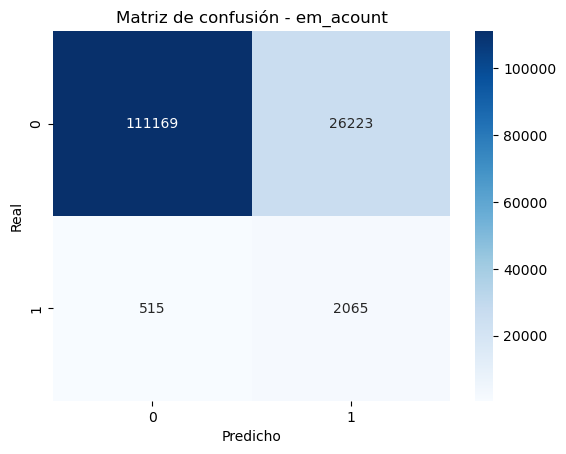

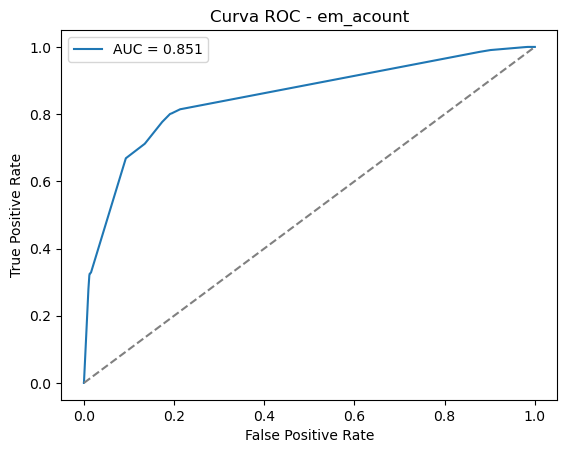

In [25]:
#modelado
modelo_em = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
modelo_em.fit(X_train_em, y_train_em)

y_pred_em = modelo_em.predict(X_test_em)
y_proba_em = modelo_em.predict_proba(X_test_em)[:, 1]

print(classification_report(y_test_em, y_pred_em, target_names=['No compra', 'Compra']))

cm_em = confusion_matrix(y_test_em, y_pred_em)
sns.heatmap(cm_em, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusión - em_acount')
plt.show()

fpr_em, tpr_em, _ = roc_curve(y_test_em, y_proba_em)
roc_auc_em = auc(fpr_em, tpr_em)
plt.plot(fpr_em, tpr_em, label=f'AUC = {roc_auc_em:.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - em_acount')
plt.legend()
plt.show()

In [26]:
val_proba_em = modelo_em.predict_proba(X_val_em)[:, 1]

df_sim_em = pd.DataFrame({
    'pk_cid': val_em['pk_cid'].values,
    'probabilidad': val_proba_em,
    'compra_real': y_val_em.values
}).sort_values(by='probabilidad', ascending=False)

top_pct = 0.05
top_n_em = int(len(df_sim_em) * top_pct)
top_clientes_em = df_sim_em.head(top_n_em)

compras_en_top_em = top_clientes_em['compra_real'].sum()
tasa_conversion_top_em = compras_en_top_em / top_n_em
tasa_base_em = df_sim_em['compra_real'].mean()

print(f"Clientes evaluados en validación (mayo 2019): {len(df_sim_em)}")
print(f"Clientes en el top {top_pct*100:.0f}%: {top_n_em}")
print(f"Compras reales dentro del top: {compras_en_top_em}")
print(f"Tasa de conversión en el top {top_pct*100:.0f}%: {tasa_conversion_top_em*100:.2f}%")
print(f"Tasa de conversión si contactases al azar: {tasa_base_em*100:.2f}%")
print(f"El modelo mejora la conversión x{tasa_conversion_top_em/tasa_base_em:.1f} frente a contactar al azar")

Clientes evaluados en validación (mayo 2019): 142598
Clientes en el top 5%: 7129
Compras reales dentro del top: 1128
Tasa de conversión en el top 5%: 15.82%
Tasa de conversión si contactases al azar: 1.73%
El modelo mejora la conversión x9.1 frente a contactar al azar


# short_term_deposit y long_term_deposit

In [27]:
for prod in ['short_term_deposit', 'long_term_deposit']:
    target_tmp = df_panel.groupby('pk_cid')[prod].diff()
    target_tmp = target_tmp.apply(lambda x: 1 if x == 1 else 0)
    lag_tmp = df_panel.groupby('pk_cid')[prod].shift(1)

    elegibles = (lag_tmp == 0)
    total_elegibles = elegibles.sum()
    total_positivos = target_tmp[elegibles].sum()

    print(f'--- {prod} ---')
    print(f'Universo elegible: {total_elegibles}')
    print(f'Adquisiciones nuevas (target=1): {total_positivos}')
    print(f'Tasa de positivos: {total_positivos / total_elegibles * 100:.4f}%')
    print()

--- short_term_deposit ---
Universo elegible: 5490143
Adquisiciones nuevas (target=1): 2565
Tasa de positivos: 0.0467%

--- long_term_deposit ---
Universo elegible: 5411175
Adquisiciones nuevas (target=1): 3997
Tasa de positivos: 0.0739%

